In [92]:

import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt

load_dotenv()

True

In [93]:
import pandas as pd
import numpy as np

# ENTENDIENDO MIS DATOS

In [94]:
sensores_df = pd.read_csv("../Data/archive/sensor_meta_feature.csv", sep=None, engine="python")

In [95]:
sensores_df.columns

Index(['Fwy Name', 'District', 'County', 'City', 'Abs PM', 'Length',
       'station_id', 'Name', 'Type', 'Sensor Type', 'HOV', 'Road Width',
       'Lane Width', 'Inner Shoulder Width', 'Outer Shoulder Width',
       'Design Speed Limit', 'Inner Median Type', 'Inner Median Width',
       'Terrain', 'Population', 'Barrier', 'Surface', 'Roadway Use', 'Lat',
       'Lng', 'Direction', 'Fwy'],
      dtype='str')

In [96]:
sensores_df.columns

Index(['Fwy Name', 'District', 'County', 'City', 'Abs PM', 'Length',
       'station_id', 'Name', 'Type', 'Sensor Type', 'HOV', 'Road Width',
       'Lane Width', 'Inner Shoulder Width', 'Outer Shoulder Width',
       'Design Speed Limit', 'Inner Median Type', 'Inner Median Width',
       'Terrain', 'Population', 'Barrier', 'Surface', 'Roadway Use', 'Lat',
       'Lng', 'Direction', 'Fwy'],
      dtype='str')

In [97]:
node_order = np.load(
    "../Data/archive/node_order.npy",
    allow_pickle=True
)
node_order

array([  1210574, 501021032,    314421, ...,    408004,    402138,
          320457], shape=(16972,))

In [98]:

print(type(node_order))
print(node_order.shape)
print(node_order[:20])

<class 'numpy.ndarray'>
(16972,)
[  1210574 501021032    314421  10119710   1211784    819941   1038410
    770545    407290    767801    826548    407153    718162   1093510
    769985  10120910 501012032   1218405   1212230    602338]


In [99]:
sensores_df[sensores_df['station_id']==node_order[0]]

,Fwy Name,District,County,City,Abs PM,Length,station_id,Name,Type,Sensor Type,...,Inner Median Width,Terrain,Population,Barrier,Surface,Roadway Use,Lat,Lng,Direction,Fwy
6205,SR73-S,12,Orange,NaN,4.95,0.28,1210574,LAGUNA HILLS,Mainline,loops,...,99 ft,Rolling,Urbanized,No Barriers,"Base & Surface >= 7"" Thick",NaN,33.585421,-117.728504,S,73


ENTONCES NODE_ORDER ES UN ARRAY DE LOS NODOS QUE ESTAN EN EL DATASET, Y SENSORES_DF ES UN DATAFRAME CON INFORMACION DE CADA NODO. SE RELACIONAN POR EL STATION_ID, QUE ES EL MISMO QUE EL NODE_ORDER. ENTONCES SI QUIERO SABER LA INFORMACION DE UN NODO, PUEDO HACER SENSORES_DF[SENSORES_DF['STATION_ID']==NODE_ORDER[0]] PARA OBTENER LA INFORMACION DEL PRIMER NODO.

In [100]:
# ENTENDIENDO LOS ARCHIVOS DE TRAFICO

traffic = np.load("../Data/archive/year_2024/year_2024/2024_p01.npy", allow_pickle=True, mmap_mode="r")

In [101]:
print(type(traffic))
print(traffic.shape)
print(traffic.dtype)

<class 'numpy.memmap'>
(16972, 8928, 3)
float64


In [102]:
traffic[0]

memmap([[7.00e+00, 3.80e-03, 6.52e+01],
        [7.00e+00, 3.40e-03, 6.52e+01],
        [7.00e+00, 3.30e-03, 6.52e+01],
        ...,
        [7.00e+00, 3.40e-03, 6.52e+01],
        [7.00e+00, 3.10e-03, 6.52e+01],
        [7.00e+00, 2.80e-03, 6.52e+01]], shape=(8928, 3))

In [103]:
traffic[0, 0, :]

memmap([7.00e+00, 3.80e-03, 6.52e+01])

ESTE DATASET ES EL DE TRAFICO. TIENE LA INFORMACION DE CADA NODO. CADA NODO TIENE 3 VARIABLES: FLOW, OCUPACION Y VELOCIDAD. TENEMOS 8928 MEDICIONES POR NODO POR MES.

[NODO 1 [ 8928*[ FLOW, OCUPACION, VELOCIDAD] ],
NODO 2 [ 8928*[ FLOW, OCUPACION, VELOCIDAD] ],
...
NODO 16972 [ 8928*[ FLOW, OCUPACION, VELOCIDAD] ]
]

O

```
[
  Nodo/Sensor 1 [
    timestamp 1: [flow, occupancy, speed],
    timestamp 2: [flow, occupancy, speed],
    ...
    timestamp 8928: [flow, occupancy, speed]
  ],

  Nodo/Sensor 2 [
    timestamp 1: [flow, occupancy, speed],
    timestamp 2: [flow, occupancy, speed],
    ...
    timestamp 8928: [flow, occupancy, speed]
  ],

  ...

  Nodo/Sensor 16972 [
    timestamp 1: [flow, occupancy, speed],
    timestamp 2: [flow, occupancy, speed],
    ...
    timestamp 8928: [flow, occupancy, speed]
  ]
]
```

In [104]:
#Vamos a transformar esto en un dataframe para poder analizarlo mejor.
sensor_index = 13351
sensor_id = node_order[sensor_index]

sensor_data = traffic[sensor_index, :, :]

df_sensor = pd.DataFrame(
    sensor_data,
    columns=["flow", "occupancy", "speed"]
)

In [105]:
df_sensor

,flow,occupancy,speed
0,243.0,0.0424,70.2
1,244.0,0.0400,70.3
2,236.0,0.0397,69.9
3,234.0,0.0393,69.6
4,217.0,0.0364,69.5
...,...,...,...
8923,298.0,0.0524,70.4
8924,287.0,0.0525,69.7
8925,273.0,0.0497,70.1
8926,275.0,0.0505,69.8


GENERAMOS UN TIMESTAMP PARA CADA UNA DE LAS 8928 MEDICIONES, QUE SON CADA 5 MINUTOS. ENTONCES TENEMOS UN RANGO DE FECHAS DESDE EL 1 DE ENERO DE 2024 HASTA EL 31 DE ENERO DE 2024. NECESITAMOS UNA MEDICION DE TIEMPO PARA PODER HACER UN ANALISIS TEMPORAL DE LOS DATOS. ENTONCES VAMOS A GENERAR UN RANGO DE FECHAS CON FRECUENCIA DE 5 MINUTOS.

AQUI PODEMOS HACERLO PORQUE DA EXACTAMENTE 8928 MEDICIONES, PERO SI NO FUERA ASI, TENDRIAMOS QUE HACERLO DE OTRA MANERA. ENTONCES VAMOS A GENERAR UN RANGO DE FECHAS CON FRECUENCIA DE 5 MINUTOS.

In [106]:
df_sensor["timestamp"] = pd.date_range(
    start="2024-01-01 00:00:00",
    periods=len(df_sensor),
    freq="5min"
)

df_sensor["sensor_index"] = sensor_index
df_sensor["sensor_id"] = sensor_id

df_sensor.head()

,flow,occupancy,speed,timestamp,sensor_index,sensor_id
0,243.0,0.0424,70.2,2024-01-01 00:00:00,13351,764853
1,244.0,0.0400,70.3,2024-01-01 00:05:00,13351,764853
2,236.0,0.0397,69.9,2024-01-01 00:10:00,13351,764853
3,234.0,0.0393,69.6,2024-01-01 00:15:00,13351,764853
4,217.0,0.0364,69.5,2024-01-01 00:20:00,13351,764853


In [107]:
df_sensor.info()

<class 'pandas.DataFrame'>
RangeIndex: 8928 entries, 0 to 8927
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   flow          8928 non-null   float64       
 1   occupancy     8928 non-null   float64       
 2   speed         8928 non-null   float64       
 3   timestamp     8928 non-null   datetime64[us]
 4   sensor_index  8928 non-null   int64         
 5   sensor_id     8928 non-null   int64         
dtypes: datetime64[us](1), float64(3), int64(2)
memory usage: 418.6 KB


In [108]:
df_sensor.describe()

,flow,occupancy,speed,timestamp,sensor_index,sensor_id
count,8928.000000,8928.000000,8928.000000,8928,8928.0,8928.0
mean,400.826165,0.191417,46.069982,2024-01-16 11:57:30,13351.0,764853.0
min,90.000000,0.018100,13.100000,2024-01-01 00:00:00,13351.0,764853.0
25%,328.000000,0.057700,22.300000,2024-01-08 17:58:45,13351.0,764853.0
50%,456.000000,0.141250,57.500000,2024-01-16 11:57:30,13351.0,764853.0
75%,498.000000,0.322800,69.100000,2024-01-24 05:56:15,13351.0,764853.0
max,586.000000,0.424500,73.400000,2024-01-31 23:55:00,13351.0,764853.0
std,139.398537,0.135824,22.944500,NaN,0.0,0.0


In [109]:
# MISSING VALUES
df_sensor.isnull().sum()

flow            0
occupancy       0
speed           0
timestamp       0
sensor_index    0
sensor_id       0
dtype: int64

In [110]:
(df_sensor[["flow", "occupancy", "speed"]] == 0).sum()

flow         0
occupancy    0
speed        0
dtype: int64

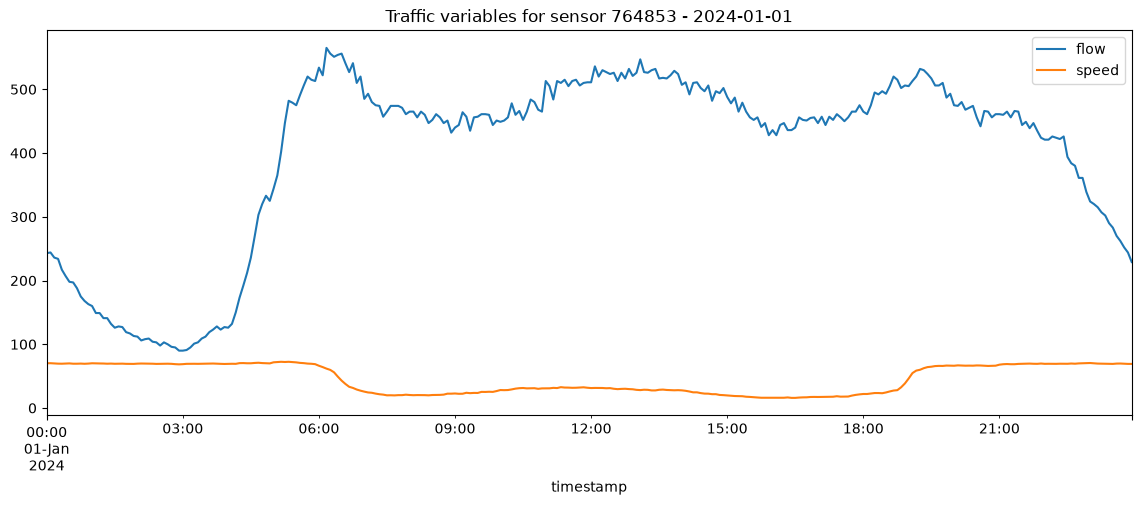

In [111]:
one_day = df_sensor[
    (df_sensor["timestamp"] >= "2024-01-01") &
    (df_sensor["timestamp"] < "2024-01-02")
]

one_day.plot(
    x="timestamp",
    y=["flow", "speed"],
    figsize=(14, 5)
)

plt.title(f"Traffic variables for sensor {sensor_id} - 2024-01-01")
plt.show()

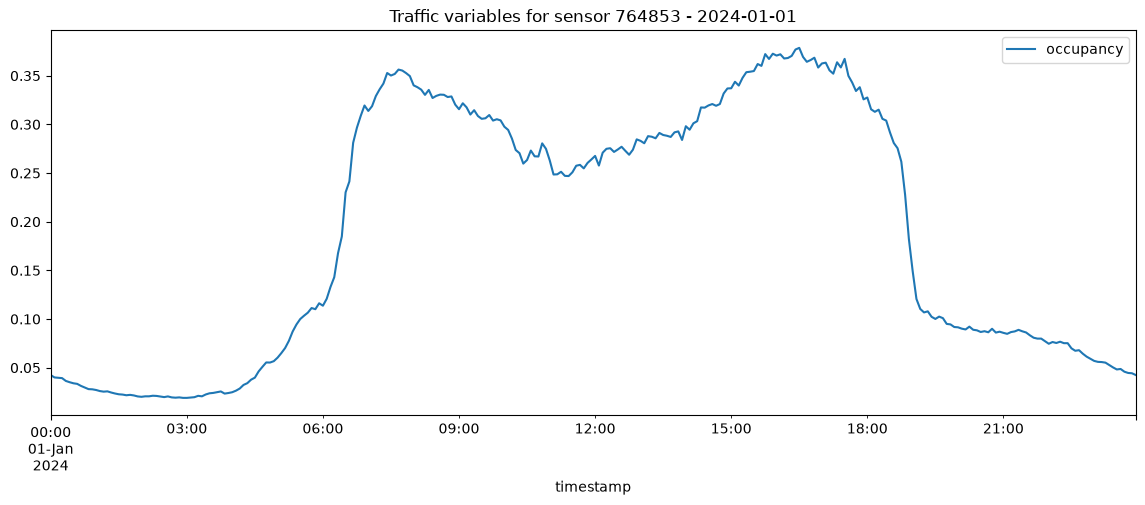

In [112]:
one_day = df_sensor[
    (df_sensor["timestamp"] >= "2024-01-01") &
    (df_sensor["timestamp"] < "2024-01-02")
]

one_day.plot(
    x="timestamp",
    y=["occupancy"],
    figsize=(14, 5)
)

plt.title(f"Traffic variables for sensor {sensor_id} - 2024-01-01")
plt.show()

PORQUE HICIMOS TODO ESTO???

¿Entiendo la forma del array?
¿Sé qué representa cada dimensión?
¿Puedo conectar sensor_index con sensor_id?
¿Puedo convertir un sensor en una tabla normal?
¿Las variables tienen sentido?
¿La gráfica se ve razonable?

In [113]:
# Vamos a hacer un analisis ahora para todos los sensores de enero del 2024.

sumary_rows = []
for sensor_index in range(traffic.shape[0]):
    sensor_data = traffic[sensor_index, :, :]
    flow = sensor_data[:, 0]
    occupancy = sensor_data[:, 1]
    speed = sensor_data[:, 2]
    
    row = {
        "sensor_index": sensor_index,
        "sensor_id": node_order[sensor_index],
        "flow_mean": np.nanmean(flow),
        "flow_std": np.nanstd(flow),
        "occupancy_mean": np.nanmean(occupancy),
        "occupancy_std": np.nanstd(occupancy),
        "speed_mean": np.nanmean(speed),
        "speed_std": np.nanstd(speed),
        "speed_min": np.nanmin(speed),
        "speed_max": np.nanmax(speed),
        "zero_speed_rate": np.mean(speed == 0),
        "slow_speed_rate_30": np.mean(speed < 30),
        "slow_speed_rate_40": np.mean(speed < 40),
    }
    sumary_rows.append(row)
    
sensor_summary_df = pd.DataFrame(sumary_rows)
sensor_summary_df.head()

,sensor_index,sensor_id,flow_mean,flow_std,occupancy_mean,occupancy_std,speed_mean,speed_std,speed_min,speed_max,zero_speed_rate,slow_speed_rate_30,slow_speed_rate_40
0,0,1210574,54.292899,36.703057,0.026769,0.019118,64.224630,1.374812,57.8,65.5,0.0,0.0,0.0
1,1,501021032,53.348454,40.479060,0.021559,0.016133,67.111514,1.204211,61.6,71.3,0.0,0.0,0.0
2,2,314421,11.338374,8.525360,0.000000,0.000000,0.000000,0.000000,0.0,0.0,1.0,1.0,1.0
3,3,10119710,204.368952,89.903592,0.052722,0.023459,66.813698,2.040639,50.5,70.6,0.0,0.0,0.0
4,4,1211784,38.668123,35.043844,0.018874,0.017224,66.128091,3.980618,42.0,72.1,0.0,0.0,0.0


In [114]:
sensor_summary_df.sort_values(
    by="speed_std",
    ascending=False
).head(20)

,sensor_index,sensor_id,flow_mean,flow_std,occupancy_mean,occupancy_std,speed_mean,speed_std,speed_min,speed_max,zero_speed_rate,slow_speed_rate_30,slow_speed_rate_40
14561,14561,767722,219.162970,202.510859,0.043595,0.042377,42.095083,30.746336,0.0,77.5,0.340054,0.342182,0.345094
9237,9237,764096,195.567092,193.202065,0.037613,0.038766,41.790177,30.732007,0.0,77.2,0.343974,0.344870,0.344982
9698,9698,717318,258.522849,224.053767,0.052022,0.048021,44.267652,29.801396,0.0,78.3,0.303875,0.304996,0.308132
11729,11729,717162,234.183020,218.500156,0.067676,0.093292,35.206765,29.735748,0.0,81.9,0.347558,0.467854,0.519377
452,452,717167,246.136313,226.053697,0.073294,0.096688,35.287522,29.458204,0.0,80.9,0.349350,0.461246,0.505152
15428,15428,717320,277.495408,242.277105,0.072503,0.089689,39.415300,28.993762,0.0,82.3,0.301187,0.382504,0.412522
15878,15878,774799,239.045587,170.944175,0.039449,0.027443,54.738094,24.390134,0.0,76.6,0.163082,0.163082,0.163082
14698,14698,819086,189.577621,78.129466,0.157725,0.139008,45.399552,23.409233,3.6,79.5,0.000000,0.355287,0.386985
4252,4252,717046,400.826165,139.390730,0.191417,0.135817,46.069982,22.943215,13.1,73.4,0.000000,0.423499,0.477263
5814,5814,716942,400.826165,139.390730,0.191417,0.135817,46.069982,22.943215,13.1,73.4,0.000000,0.423499,0.477263


In [115]:
good_sensors = sensor_summary_df[
    (sensor_summary_df["zero_speed_rate"] < 0.05) &
    (sensor_summary_df["speed_mean"] > 20) &
    (sensor_summary_df["slow_speed_rate_30"] > 0.01) &
    (sensor_summary_df["slow_speed_rate_30"] < 0.40)
]

good_sensors = good_sensors.sort_values(
    by=["speed_std", "slow_speed_rate_30"],
    ascending=False
)

good_sensors.head(20)

,sensor_index,sensor_id,flow_mean,flow_std,occupancy_mean,occupancy_std,speed_mean,speed_std,speed_min,speed_max,zero_speed_rate,slow_speed_rate_30,slow_speed_rate_40
14698,14698,819086,189.577621,78.129466,0.157725,0.139008,45.399552,23.409233,3.6,79.5,0.0,0.355287,0.386985
3247,3247,716924,329.327061,134.492350,0.160625,0.140429,49.557157,22.213678,3.8,76.0,0.0,0.271281,0.342294
16418,16418,315885,18.448141,14.949699,0.011320,0.010647,43.886447,21.504527,3.0,99.0,0.0,0.344870,0.516353
15305,15305,817029,240.734543,116.197413,0.093651,0.107161,56.327408,21.002920,6.2,74.5,0.0,0.194780,0.201053
9285,9285,716922,365.030018,149.593515,0.151077,0.122726,50.528517,20.624218,5.8,77.8,0.0,0.255152,0.342294
12402,12402,717894,288.244176,117.430583,0.129417,0.120507,52.487478,20.349931,3.0,75.2,0.0,0.223342,0.266017
12179,12179,774729,295.674395,142.290370,0.129340,0.124261,52.432897,20.276258,5.3,75.1,0.0,0.239471,0.261761
8944,8944,717788,404.290659,161.182555,0.118423,0.107494,52.597133,19.974949,4.7,76.6,0.0,0.191756,0.234319
2843,2843,716714,458.819444,212.482331,0.161454,0.132144,52.518134,19.950877,12.3,81.2,0.0,0.255152,0.361447
3581,3581,401819,119.917787,59.105994,0.134315,0.118706,47.158333,19.826522,9.3,79.8,0.0,0.242047,0.414427


In [116]:
good_sensors["sensor_id_str"] = good_sensors["sensor_id"].astype(str)
sensores_df["station_id_str"] = sensores_df["station_id"].astype(str)

good_sensors_with_meta = good_sensors.merge(
    sensores_df,
    left_on="sensor_id_str",
    right_on="station_id_str",
    how="left"
)

good_sensors_with_meta.head(20)

,sensor_index,sensor_id,flow_mean,flow_std,occupancy_mean,occupancy_std,speed_mean,speed_std,speed_min,speed_max,...,Terrain,Population,Barrier,Surface,Roadway Use,Lat,Lng,Direction,Fwy,station_id_str
0,14698,819086,189.577621,78.129466,0.157725,0.139008,45.399552,23.409233,3.6,79.5,...,Flat,Urbanized,Concrete Barrier,"Base & Surface >= 7"" Thick",No Special Features,33.933734,-117.289503,N,215,819086
1,3247,716924,329.327061,134.492350,0.160625,0.140429,49.557157,22.213678,3.8,76.0,...,Flat,Urbanized,Concrete Barrier w/Glare Screen,Concrete,No Special Features,33.994935,-118.144690,S,5,716924
2,16418,315885,18.448141,14.949699,0.011320,0.010647,43.886447,21.504527,3.0,99.0,...,Flat,Urbanized,Three Beam Barrier,Concrete,No Special Features,38.674742,-121.345690,W,80,315885
3,15305,817029,240.734543,116.197413,0.093651,0.107161,56.327408,21.002920,6.2,74.5,...,Rolling,Urban,No Barriers,"Base & Surface >= 7"" Thick",No Special Features,33.481651,-117.140861,N,15,817029
4,9285,716922,365.030018,149.593515,0.151077,0.122726,50.528517,20.624218,5.8,77.8,...,Flat,Urbanized,Metal Beam Barrier w/Glare Screen,Concrete,No Special Features,33.986224,-118.136014,S,5,716922
5,12402,717894,288.244176,117.430583,0.129417,0.120507,52.487478,20.349931,3.0,75.2,...,Flat,Urbanized,Concrete Barrier,Concrete,Median Lane is HOV Lane,33.972515,-118.080722,S,605,717894
6,12179,774729,295.674395,142.290370,0.129340,0.124261,52.432897,20.276258,5.3,75.1,...,Flat,Urbanized,Concrete Barrier w/Glare Screen,Bridge Deck,No Special Features,34.081536,-117.728631,E,10,774729
7,8944,717788,404.290659,161.182555,0.118423,0.107494,52.597133,19.974949,4.7,76.6,...,Flat,Urbanized,Concrete Barrier w/Glare Screen,Bridge Deck,No Special Features,34.004651,-118.412662,S,405,717788
8,2843,716714,458.819444,212.482331,0.161454,0.132144,52.518134,19.950877,12.3,81.2,...,Flat,Urbanized,Concrete Barrier w/Glare Screen,Concrete,No Special Features,34.018964,-118.423660,N,405,716714
9,3581,401819,119.917787,59.105994,0.134315,0.118706,47.158333,19.826522,9.3,79.8,...,Flat,Urbanized,Bridge barrier Railing,Bridge Deck,NaN,37.770070,-122.419351,N,101,401819


In [117]:
candidate = good_sensors_with_meta.iloc[0]

candidate

sensor_index                                 14698
sensor_id                                   819086
flow_mean                               189.577621
flow_std                                 78.129466
occupancy_mean                            0.157725
occupancy_std                             0.139008
speed_mean                               45.399552
speed_std                                23.409233
speed_min                                      3.6
speed_max                                     79.5
zero_speed_rate                                0.0
slow_speed_rate_30                        0.355287
slow_speed_rate_40                        0.386985
sensor_id_str                               819086
Fwy Name                                    I215-N
District                                         8
County                                   Riverside
City                                           NaN
Abs PM                                      29.267
Length                         

In [118]:
selected_sensor_index = int(candidate["sensor_index"])
selected_sensor_id = candidate["sensor_id"]

print("Selected sensor index:", selected_sensor_index)
print("Selected sensor ID:", selected_sensor_id)

Selected sensor index: 14698
Selected sensor ID: 819086


In [119]:
selected_data = traffic[selected_sensor_index, :, :]

df_selected = pd.DataFrame(
    selected_data,
    columns=["flow", "occupancy", "speed"]
)

df_selected["timestamp"] = pd.date_range(
    start="2024-01-01",
    periods=len(df_selected),
    freq="5min"
)

df_selected["sensor_index"] = selected_sensor_index
df_selected["sensor_id"] = selected_sensor_id

df_selected.head()

,flow,occupancy,speed,timestamp,sensor_index,sensor_id
0,54.0,0.0125,68.8,2024-01-01 00:00:00,14698,819086
1,27.0,0.0068,68.4,2024-01-01 00:05:00,14698,819086
2,28.0,0.0082,68.1,2024-01-01 00:10:00,14698,819086
3,83.0,0.0196,68.1,2024-01-01 00:15:00,14698,819086
4,123.0,0.0303,68.0,2024-01-01 00:20:00,14698,819086


In [120]:
df_selected["date"] = df_selected["timestamp"].dt.date

daily_summary = df_selected.groupby("date").agg(
    avg_speed=("speed", "mean"),
    min_speed=("speed", "min"),
    speed_std=("speed", "std"),
    slow_rate_30=("speed", lambda x: (x < 30).mean()),
    flow_mean=("flow", "mean"),
    occupancy_mean=("occupancy", "mean")
).reset_index()

daily_summary.sort_values("slow_rate_30", ascending=False).head(10)

,date,avg_speed,min_speed,speed_std,slow_rate_30,flow_mean,occupancy_mean
25,2024-01-26,35.198264,8.4,22.601562,0.562500,199.996528,0.221065
28,2024-01-29,38.120139,7.2,24.445029,0.534722,178.055556,0.202635
11,2024-01-12,37.490625,7.7,26.523898,0.531250,180.017361,0.224128
29,2024-01-30,39.421528,4.8,26.069131,0.500000,176.840278,0.213452
24,2024-01-25,39.397917,6.8,24.556691,0.493056,190.197917,0.203619
15,2024-01-16,39.044097,5.9,24.005298,0.482639,180.468750,0.193910
9,2024-01-10,39.277083,7.8,25.322470,0.482639,177.385417,0.200870
17,2024-01-18,40.814236,7.5,25.763902,0.479167,188.045139,0.199203
10,2024-01-11,40.927431,7.8,24.816314,0.479167,180.642361,0.191710
30,2024-01-31,39.815278,3.6,27.107731,0.465278,164.736111,0.206176


<Axes: title={'center': 'Speed - Sensor 819086 - 2024-01-26'}, xlabel='timestamp'>

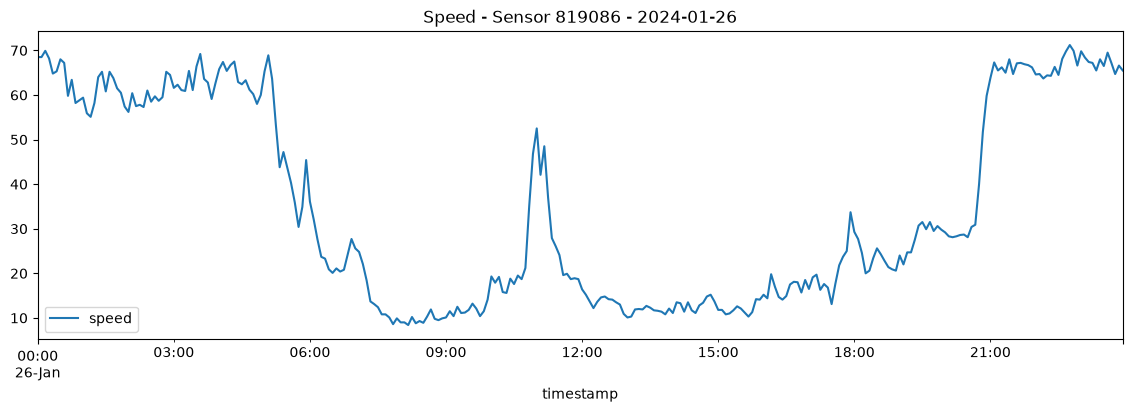

In [121]:
worst_day = daily_summary.sort_values(
    "slow_rate_30",
    ascending=False
).iloc[0]["date"]

one_day = df_selected[df_selected["date"] == worst_day]
mean = one_day["speed"].mean()
one_day.plot(
    x="timestamp",
    y="speed",
    figsize=(14, 4),
    title=f"Speed - Sensor {selected_sensor_id} - {worst_day}"
)

<Axes: title={'center': 'Flow - Sensor 819086 - 2024-01-26'}, xlabel='timestamp'>

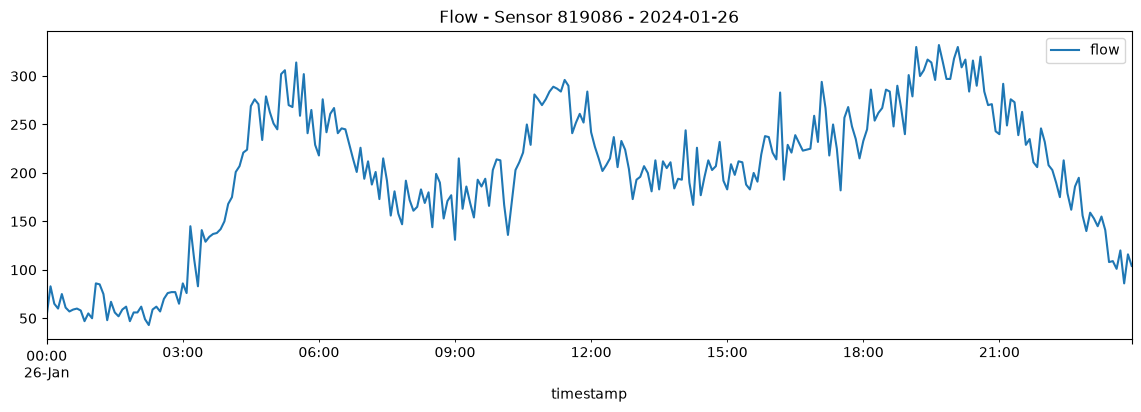

In [122]:
one_day.plot(
    x="timestamp",
    y="flow",
    figsize=(14, 4),
    title=f"Flow - Sensor {selected_sensor_id} - {worst_day}"
)

<Axes: title={'center': 'Occupancy - Sensor 819086 - 2024-01-26'}, xlabel='timestamp'>

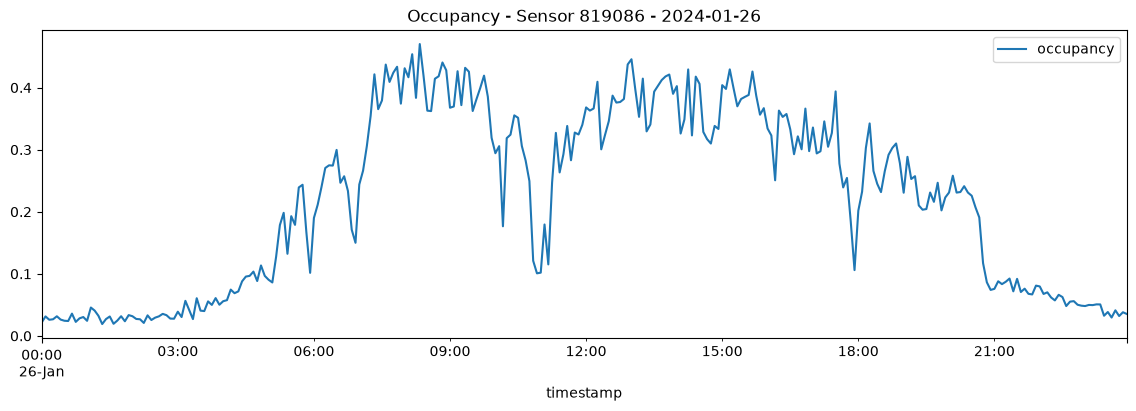

In [123]:
one_day.plot(
    x="timestamp",
    y="occupancy",
    figsize=(14, 4),
    title=f"Occupancy - Sensor {selected_sensor_id} - {worst_day}"
)

In [124]:
good_sensors_with_meta.head(20)

,sensor_index,sensor_id,flow_mean,flow_std,occupancy_mean,occupancy_std,speed_mean,speed_std,speed_min,speed_max,...,Terrain,Population,Barrier,Surface,Roadway Use,Lat,Lng,Direction,Fwy,station_id_str
0,14698,819086,189.577621,78.129466,0.157725,0.139008,45.399552,23.409233,3.6,79.5,...,Flat,Urbanized,Concrete Barrier,"Base & Surface >= 7"" Thick",No Special Features,33.933734,-117.289503,N,215,819086
1,3247,716924,329.327061,134.492350,0.160625,0.140429,49.557157,22.213678,3.8,76.0,...,Flat,Urbanized,Concrete Barrier w/Glare Screen,Concrete,No Special Features,33.994935,-118.144690,S,5,716924
2,16418,315885,18.448141,14.949699,0.011320,0.010647,43.886447,21.504527,3.0,99.0,...,Flat,Urbanized,Three Beam Barrier,Concrete,No Special Features,38.674742,-121.345690,W,80,315885
3,15305,817029,240.734543,116.197413,0.093651,0.107161,56.327408,21.002920,6.2,74.5,...,Rolling,Urban,No Barriers,"Base & Surface >= 7"" Thick",No Special Features,33.481651,-117.140861,N,15,817029
4,9285,716922,365.030018,149.593515,0.151077,0.122726,50.528517,20.624218,5.8,77.8,...,Flat,Urbanized,Metal Beam Barrier w/Glare Screen,Concrete,No Special Features,33.986224,-118.136014,S,5,716922
5,12402,717894,288.244176,117.430583,0.129417,0.120507,52.487478,20.349931,3.0,75.2,...,Flat,Urbanized,Concrete Barrier,Concrete,Median Lane is HOV Lane,33.972515,-118.080722,S,605,717894
6,12179,774729,295.674395,142.290370,0.129340,0.124261,52.432897,20.276258,5.3,75.1,...,Flat,Urbanized,Concrete Barrier w/Glare Screen,Bridge Deck,No Special Features,34.081536,-117.728631,E,10,774729
7,8944,717788,404.290659,161.182555,0.118423,0.107494,52.597133,19.974949,4.7,76.6,...,Flat,Urbanized,Concrete Barrier w/Glare Screen,Bridge Deck,No Special Features,34.004651,-118.412662,S,405,717788
8,2843,716714,458.819444,212.482331,0.161454,0.132144,52.518134,19.950877,12.3,81.2,...,Flat,Urbanized,Concrete Barrier w/Glare Screen,Concrete,No Special Features,34.018964,-118.423660,N,405,716714
9,3581,401819,119.917787,59.105994,0.134315,0.118706,47.158333,19.826522,9.3,79.8,...,Flat,Urbanized,Bridge barrier Railing,Bridge Deck,NaN,37.770070,-122.419351,N,101,401819


In [125]:
daily_summary.sort_values("slow_rate_30", ascending=False).head(10)

,date,avg_speed,min_speed,speed_std,slow_rate_30,flow_mean,occupancy_mean
25,2024-01-26,35.198264,8.4,22.601562,0.562500,199.996528,0.221065
28,2024-01-29,38.120139,7.2,24.445029,0.534722,178.055556,0.202635
11,2024-01-12,37.490625,7.7,26.523898,0.531250,180.017361,0.224128
29,2024-01-30,39.421528,4.8,26.069131,0.500000,176.840278,0.213452
24,2024-01-25,39.397917,6.8,24.556691,0.493056,190.197917,0.203619
15,2024-01-16,39.044097,5.9,24.005298,0.482639,180.468750,0.193910
9,2024-01-10,39.277083,7.8,25.322470,0.482639,177.385417,0.200870
17,2024-01-18,40.814236,7.5,25.763902,0.479167,188.045139,0.199203
10,2024-01-11,40.927431,7.8,24.816314,0.479167,180.642361,0.191710
30,2024-01-31,39.815278,3.6,27.107731,0.465278,164.736111,0.206176


In [126]:
df_selected["is_congested"] = (df_selected["speed"] < 30).astype(int)

df_selected[["timestamp", "speed", "is_congested"]].head()

,timestamp,speed,is_congested
0,2024-01-01 00:00:00,68.8,0
1,2024-01-01 00:05:00,68.4,0
2,2024-01-01 00:10:00,68.1,0
3,2024-01-01 00:15:00,68.1,0
4,2024-01-01 00:20:00,68.0,0


In [127]:
df_selected["is_congested"].mean()

np.float64(0.35528673835125446)

In [128]:
df_selected["is_congested"] = (df_selected["speed"] < 30).astype(int)

df_selected[["timestamp", "speed", "occupancy", "flow", "is_congested"]].head()

,timestamp,speed,occupancy,flow,is_congested
0,2024-01-01 00:00:00,68.8,0.0125,54.0,0
1,2024-01-01 00:05:00,68.4,0.0068,27.0,0
2,2024-01-01 00:10:00,68.1,0.0082,28.0,0
3,2024-01-01 00:15:00,68.1,0.0196,83.0,0
4,2024-01-01 00:20:00,68.0,0.0303,123.0,0


In [129]:
df_selected["is_congested"].mean()

np.float64(0.35528673835125446)

In [130]:
one_day = df_selected[df_selected["date"] == pd.to_datetime("2024-01-26").date()].copy()

one_day["block"] = (
    one_day["is_congested"] != one_day["is_congested"].shift()
).cumsum()

congestion_blocks = (
    one_day
    .groupby("block")
    .agg(
        is_congested=("is_congested", "first"),
        start_time=("timestamp", "min"),
        end_time=("timestamp", "max"),
        n_points=("timestamp", "count"),
        avg_speed=("speed", "mean"),
        min_speed=("speed", "min"),
        avg_occupancy=("occupancy", "mean"),
        avg_flow=("flow", "mean")
    )
    .reset_index()
)

congestion_blocks = congestion_blocks[
    congestion_blocks["is_congested"] == 1
].copy()

congestion_blocks["duration_minutes"] = congestion_blocks["n_points"] * 5

congestion_blocks.sort_values("duration_minutes", ascending=False)

,block,is_congested,start_time,end_time,n_points,avg_speed,min_speed,avg_occupancy,avg_flow,duration_minutes
3,4,1,2024-01-26 11:20:00,2024-01-26 17:50:00,79,14.968354,10.1,0.351510,221.164557,395
1,2,1,2024-01-26 06:10:00,2024-01-26 10:45:00,56,15.155357,8.4,0.347437,194.678571,280
5,6,1,2024-01-26 18:00:00,2024-01-26 19:20:00,17,23.770588,20.0,0.265241,275.176471,85
11,12,1,2024-01-26 19:55:00,2024-01-26 20:30:00,8,28.637500,28.1,0.234088,307.625000,40
7,8,1,2024-01-26 19:35:00,2024-01-26 19:35:00,1,29.900000,29.9,0.231000,296.000000,5
9,10,1,2024-01-26 19:45:00,2024-01-26 19:45:00,1,29.500000,29.5,0.246700,315.000000,5


In [131]:
df_model = df_selected.copy()

df_model["is_congested"] = (df_model["speed"] < 30).astype(int)

horizons = {
    "30min": 6,
    "60min": 12,   
    "90min": 18,
    "120min": 24
}

for horizon_name, horizon_steps in horizons.items():
    df_model[f"congestion_{horizon_name}"] = df_model["is_congested"].shift(-horizon_steps)
    
target_columns = [f"congestion_{horizon_name}" for horizon_name in horizons.keys()]

df_model = df_model.dropna(
    subset=target_columns
)

for col in target_columns:
    df_model[col] = df_model[col].astype(int)
    

df_model[["timestamp", "speed", "is_congested"] + target_columns].head(20)

,timestamp,speed,is_congested,congestion_30min,congestion_60min,congestion_90min,congestion_120min
0,2024-01-01 00:00:00,68.8,0,0,0,0,0
1,2024-01-01 00:05:00,68.4,0,0,0,0,0
2,2024-01-01 00:10:00,68.1,0,0,0,0,0
3,2024-01-01 00:15:00,68.1,0,0,0,0,0
4,2024-01-01 00:20:00,68.0,0,0,0,0,0
5,2024-01-01 00:25:00,68.0,0,0,0,0,0
6,2024-01-01 00:30:00,68.2,0,0,0,0,0
7,2024-01-01 00:35:00,66.5,0,0,0,0,0
8,2024-01-01 00:40:00,65.7,0,0,0,0,0
9,2024-01-01 00:45:00,65.6,0,0,0,0,0


In [132]:
check_window = df_model[
    (df_model["timestamp"] >= "2024-01-26 05:00") &
    (df_model["timestamp"] <= "2024-01-26 06:30")
][
    [
        "timestamp",
        "speed",
        "is_congested",
        "congestion_30min",
        "congestion_60min",
        "congestion_90min",
        "congestion_120min"
    ]
]

check_window

,timestamp,speed,is_congested,congestion_30min,congestion_60min,congestion_90min,congestion_120min
7260,2024-01-26 05:00:00,65.3,0,0,0,1,1
7261,2024-01-26 05:05:00,68.9,0,0,0,1,1
7262,2024-01-26 05:10:00,63.6,0,0,1,1,1
7263,2024-01-26 05:15:00,53.2,0,0,1,1,1
7264,2024-01-26 05:20:00,43.8,0,0,1,1,1
7265,2024-01-26 05:25:00,47.2,0,0,1,1,1
7266,2024-01-26 05:30:00,43.7,0,0,1,1,1
7267,2024-01-26 05:35:00,40.3,0,0,1,1,1
7268,2024-01-26 05:40:00,35.9,0,1,1,1,1
7269,2024-01-26 05:45:00,30.4,0,1,1,1,1


In [133]:
df_model[target_columns].mean()

congestion_30min     0.356244
congestion_60min     0.356244
congestion_90min     0.356244
congestion_120min    0.356244
dtype: float64

In [134]:
early_warning_cases = df_model[
    (df_model["is_congested"] == 0) &
    (df_model["congestion_30min"] == 1)
]

early_warning_cases[
    ["timestamp", "speed", "congestion_30min", "congestion_60min", "congestion_90min", "congestion_120min"]
].head(20)

,timestamp,speed,congestion_30min,congestion_60min,congestion_90min,congestion_120min
216,2024-01-01 18:00:00,58.9,1,1,0,0
217,2024-01-01 18:05:00,59.6,1,1,0,0
218,2024-01-01 18:10:00,60.5,1,1,0,0
219,2024-01-01 18:15:00,61.2,1,1,0,0
220,2024-01-01 18:20:00,56.8,1,1,0,0
221,2024-01-01 18:25:00,41.1,1,0,0,0
373,2024-01-02 07:05:00,40.4,1,1,0,0
374,2024-01-02 07:10:00,43.7,1,1,0,0
375,2024-01-02 07:15:00,44.0,1,1,0,0
376,2024-01-02 07:20:00,46.6,1,0,0,0


ahora pasamos de:

tengo el target futuro

a:

qué información puede usar el modelo en el momento actual para predecir ese target

In [135]:
df_model = df_model.sort_values("timestamp").reset_index(drop=True)

Para forecasting, dica importante: Features de calendario. buscar hora, dia de la semana, feriados, etc. para ver si hay patrones.

In [136]:
df_model["hour"] = df_model["timestamp"].dt.hour
df_model["minute"] = df_model["timestamp"].dt.minute
df_model["day_of_week"] = df_model["timestamp"].dt.dayofweek
df_model["day"] = df_model["timestamp"].dt.day
df_model["is_weekend"] = (df_model["day_of_week"] >= 5).astype(int)

df_model[[
    "timestamp",
    "hour",
    "minute",
    "day_of_week",
    "day",
    "is_weekend"
]].head()

,timestamp,hour,minute,day_of_week,day,is_weekend
0,2024-01-01 00:00:00,0,0,0,1,0
1,2024-01-01 00:05:00,0,5,0,1,0
2,2024-01-01 00:10:00,0,10,0,1,0
3,2024-01-01 00:15:00,0,15,0,1,0
4,2024-01-01 00:20:00,0,20,0,1,0


Otra dica importante: features ciclicas. de hora...para que el modelo entienda que 23:59 y 00:00 son horas cercanas, no lejanas. Para eso podemos usar sen y cos de la hora.

In [137]:

df_model["hour_sin"] = np.sin(2 * np.pi * df_model["hour"] / 24)
df_model["hour_cos"] = np.cos(2 * np.pi * df_model["hour"] / 24)

df_model["dow_sin"] = np.sin(2 * np.pi * df_model["day_of_week"] / 7)
df_model["dow_cos"] = np.cos(2 * np.pi * df_model["day_of_week"] / 7)

# Mas adelante tenemos que agreagar no solo semana sino tambien mes, trimestre, ano, 
# etc. para que el modelo pueda aprender patrones de temporada.

In [138]:
lag_steps = {
    "5m": 1,
    "15m": 3,
    "30m": 6,
    "60m": 12, 
    "90m": 18,
}

for lag_name, steps in lag_steps.items():
    df_model[f"speed_lag_{lag_name}"] = df_model["speed"].shift(steps)
    df_model[f"flow_lag_{lag_name}"] = df_model["flow"].shift(steps)
    df_model[f"occupancy_lag_{lag_name}"] = df_model["occupancy"].shift(steps)

In [139]:
rolling_windows = {
    "15m": 3,
    "30m": 6,
    "60m": 12,
    "90m": 18
}

for window_name, window_size in rolling_windows.items():
    df_model[f"speed_roll_mean_{window_name}"] = (
        df_model["speed"].shift(1).rolling(window_size).mean()
    )
    df_model[f"speed_roll_std_{window_name}"] = (
        df_model["speed"].shift(1).rolling(window_size).std()
    )

    df_model[f"flow_roll_mean_{window_name}"] = (
        df_model["flow"].shift(1).rolling(window_size).mean()
    )

    df_model[f"occupancy_roll_mean_{window_name}"] = (
        df_model["occupancy"].shift(1).rolling(window_size).mean()
    )

In [140]:
df_model

,flow,occupancy,speed,timestamp,sensor_index,sensor_id,date,is_congested,congestion_30min,congestion_60min,...,flow_roll_mean_30m,occupancy_roll_mean_30m,speed_roll_mean_60m,speed_roll_std_60m,flow_roll_mean_60m,occupancy_roll_mean_60m,speed_roll_mean_90m,speed_roll_std_90m,flow_roll_mean_90m,occupancy_roll_mean_90m
0,54.0,0.0125,68.8,2024-01-01 00:00:00,14698,819086,2024-01-01,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,27.0,0.0068,68.4,2024-01-01 00:05:00,14698,819086,2024-01-01,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,28.0,0.0082,68.1,2024-01-01 00:10:00,14698,819086,2024-01-01,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,83.0,0.0196,68.1,2024-01-01 00:15:00,14698,819086,2024-01-01,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,123.0,0.0303,68.0,2024-01-01 00:20:00,14698,819086,2024-01-01,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8899,159.0,0.0583,67.6,2024-01-31 21:35:00,14698,819086,2024-01-31,0,0,0,...,185.166667,0.062600,67.441667,2.739429,201.250000,0.066525,66.416667,2.859093,208.666667,0.069033
8900,189.0,0.0614,69.7,2024-01-31 21:40:00,14698,819086,2024-01-31,0,0,0,...,182.000000,0.062633,67.758333,2.488321,196.250000,0.064983,66.655556,2.761334,204.333333,0.067883
8901,163.0,0.0581,67.8,2024-01-31 21:45:00,14698,819086,2024-01-31,0,0,0,...,182.500000,0.063117,68.300000,2.079773,193.166667,0.063725,67.122222,2.500484,203.388889,0.067100
8902,153.0,0.0581,65.2,2024-01-31 21:50:00,14698,819086,2024-01-31,0,0,0,...,172.833333,0.060367,68.466667,1.936413,188.666667,0.063000,67.255556,2.467011,199.833333,0.066489


In [141]:
df_model["speed_diff_5m"] = df_model["speed"] - df_model["speed_lag_5m"]
df_model["speed_diff_15m"] = df_model["speed"] - df_model["speed_lag_15m"]
df_model["speed_diff_30m"] = df_model["speed"] - df_model["speed_lag_30m"]

df_model["occupancy_diff_5m"] = df_model["occupancy"] - df_model["occupancy_lag_5m"]
df_model["occupancy_diff_15m"] = df_model["occupancy"] - df_model["occupancy_lag_15m"]

In [142]:
feature_cols = [
    "flow",
    "occupancy",
    "speed",

    "hour",
    "minute",
    "day_of_week",
    "day",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",

    "speed_lag_5m",
    "speed_lag_15m",
    "speed_lag_30m",
    "speed_lag_60m",

    "flow_lag_5m",
    "flow_lag_15m",
    "flow_lag_30m",
    "flow_lag_60m",

    "occupancy_lag_5m",
    "occupancy_lag_15m",
    "occupancy_lag_30m",
    "occupancy_lag_60m",
    "occupancy_lag_90m",

    "speed_roll_mean_15m",
    "speed_roll_mean_30m",
    "speed_roll_mean_60m",
    "speed_roll_std_15m",
    "speed_roll_std_30m",
    "speed_roll_std_60m",
    "speed_roll_std_90m",

    "flow_roll_mean_15m",
    "flow_roll_mean_30m",
    "flow_roll_mean_60m",
    "flow_roll_mean_90m",

    "occupancy_roll_mean_15m",
    "occupancy_roll_mean_30m",
    "occupancy_roll_mean_60m",
    "occupancy_roll_mean_90m",
    
    "speed_diff_5m",
    "speed_diff_15m",
    "speed_diff_30m",

    "occupancy_diff_5m",
    "occupancy_diff_15m"
]

target_cols = [
    "congestion_30min",
    "congestion_60min",
    "congestion_90min",
    "congestion_120min"
]

df_features = df_model.dropna(subset=feature_cols + target_cols).copy()

print(df_model.shape)
print(df_features.shape)

(8904, 57)
(8886, 57)


Qué acabamos de construir

Ahora cada fila representa esto:

En este timestamp tengo:
- tráfico actual
- tráfico pasado reciente
- hora/día
- tendencia reciente de velocidad
- tendencia reciente de ocupación


Y quiero predecir:
- congestión en 30 min
- congestión en 60 min
- congestión en 90 min
- congestión en 120 min

In [143]:
df_features.to_csv("../Data/processed/ONE_SENSOR_TRAFIC_DATA_ONLY.csv", index=False)

In [144]:
df_features[feature_cols + target_cols].isna().sum().sort_values(ascending=False).head(20)

flow                       0
speed_roll_mean_15m        0
speed_roll_mean_60m        0
speed_roll_std_15m         0
speed_roll_std_30m         0
speed_roll_std_60m         0
speed_roll_std_90m         0
flow_roll_mean_15m         0
flow_roll_mean_30m         0
flow_roll_mean_60m         0
flow_roll_mean_90m         0
occupancy_roll_mean_15m    0
occupancy_roll_mean_30m    0
occupancy_roll_mean_60m    0
occupancy_roll_mean_90m    0
speed_diff_5m              0
speed_diff_15m             0
speed_diff_30m             0
occupancy_diff_5m          0
occupancy_diff_15m         0
dtype: int64

In [145]:
from utils import getFilePath as ut

In [146]:
all_year_paths_2022 = ut.get_year_file(ut.BASE_DIR, "2022", ".npy")
all_year_paths_2023 = ut.get_year_file(ut.BASE_DIR, "2023", ".npy")
all_year_paths_2024 = ut.get_year_file(ut.BASE_DIR, "2024", ".npy")

Searching for files in: /Users/manuel/Mis Estudios/MLOps/END-TO-END-MLPROJECT/traffic-prediction-forecasting/Data/archive/year_2022 with extension: .npy
Searching for files in: /Users/manuel/Mis Estudios/MLOps/END-TO-END-MLPROJECT/traffic-prediction-forecasting/Data/archive/year_2023 with extension: .npy
Searching for files in: /Users/manuel/Mis Estudios/MLOps/END-TO-END-MLPROJECT/traffic-prediction-forecasting/Data/archive/year_2024 with extension: .npy


In [147]:
all_year_paths = all_year_paths_2022 + all_year_paths_2023 + all_year_paths_2024

In [148]:
for path in all_year_paths:
    print(path)
    year_data = np.load(path, allow_pickle=True, mmap_mode="r")
    print(year_data.shape)

/Users/manuel/Mis Estudios/MLOps/END-TO-END-MLPROJECT/traffic-prediction-forecasting/Data/archive/year_2022/year_2022/2022_p01.npy
(16972, 8928, 3)
/Users/manuel/Mis Estudios/MLOps/END-TO-END-MLPROJECT/traffic-prediction-forecasting/Data/archive/year_2022/year_2022/2022_p02.npy
(16972, 8064, 3)
/Users/manuel/Mis Estudios/MLOps/END-TO-END-MLPROJECT/traffic-prediction-forecasting/Data/archive/year_2022/year_2022/2022_p03.npy
(16972, 8928, 3)
/Users/manuel/Mis Estudios/MLOps/END-TO-END-MLPROJECT/traffic-prediction-forecasting/Data/archive/year_2022/year_2022/2022_p04.npy
(16972, 8640, 3)
/Users/manuel/Mis Estudios/MLOps/END-TO-END-MLPROJECT/traffic-prediction-forecasting/Data/archive/year_2022/year_2022/2022_p05.npy
(16972, 8928, 3)
/Users/manuel/Mis Estudios/MLOps/END-TO-END-MLPROJECT/traffic-prediction-forecasting/Data/archive/year_2022/year_2022/2022_p06.npy
(16972, 8640, 3)
/Users/manuel/Mis Estudios/MLOps/END-TO-END-MLPROJECT/traffic-prediction-forecasting/Data/archive/year_2022/year

In [149]:
p = '/Users/manuel/Mis Estudios/MLOps/END-TO-END-MLPROJECT/traffic-prediction-forecasting/Data/archive/year_2023/year_2023/2023_p05.npy'

In [150]:
p.split("/")[-1].split(".")[0]
month = int(p.split("/")[-1].split(".")[0][-2:])
month

5

In [151]:
def get_sensor_data(sensor_index, year_paths, year):
    all_data = []
    print(f"Getting data for sensor index: {sensor_index}")
    for path in year_paths:
        print(f"Loading data from: {path}")
        path = str(path)
        year_data = np.load(path, allow_pickle=True, mmap_mode="r")
        sensor_data = year_data[sensor_index, :, :]
        df_month = pd.DataFrame(
            sensor_data,
            columns=["flow", "occupancy", "speed"]
        )
       
        month = int(path.split("/")[-1].split(".")[0][-2:])
        df_month["timestamp"] = pd.date_range(
            start=pd.to_datetime(f"{year}-{month:02d}-01 00:00:00"),
            periods=len(df_month),
            freq="5min"
        )
        df_month["sensor_index"] = sensor_index
        df_month["sensor_id"] = node_order[sensor_index]
        all_data.append(df_month)
    df_sensor_year = pd.concat(all_data, ignore_index=True)
    df_sensor_year["date"] = df_sensor_year["timestamp"].dt.date
    df_sensor_year = df_sensor_year.sort_values("timestamp").reset_index(drop=True)
    return df_sensor_year
    

In [152]:
df_2022 = get_sensor_data(selected_sensor_index, all_year_paths, "2022")
df_2023 = get_sensor_data(selected_sensor_index, all_year_paths, "2023")
df_2024 = get_sensor_data(selected_sensor_index, all_year_paths, "2024")

Getting data for sensor index: 14698
Loading data from: /Users/manuel/Mis Estudios/MLOps/END-TO-END-MLPROJECT/traffic-prediction-forecasting/Data/archive/year_2022/year_2022/2022_p01.npy
Loading data from: /Users/manuel/Mis Estudios/MLOps/END-TO-END-MLPROJECT/traffic-prediction-forecasting/Data/archive/year_2022/year_2022/2022_p02.npy
Loading data from: /Users/manuel/Mis Estudios/MLOps/END-TO-END-MLPROJECT/traffic-prediction-forecasting/Data/archive/year_2022/year_2022/2022_p03.npy
Loading data from: /Users/manuel/Mis Estudios/MLOps/END-TO-END-MLPROJECT/traffic-prediction-forecasting/Data/archive/year_2022/year_2022/2022_p04.npy
Loading data from: /Users/manuel/Mis Estudios/MLOps/END-TO-END-MLPROJECT/traffic-prediction-forecasting/Data/archive/year_2022/year_2022/2022_p05.npy
Loading data from: /Users/manuel/Mis Estudios/MLOps/END-TO-END-MLPROJECT/traffic-prediction-forecasting/Data/archive/year_2022/year_2022/2022_p06.npy
Loading data from: /Users/manuel/Mis Estudios/MLOps/END-TO-END-

In [153]:
time_diff = df_2022["timestamp"].diff()

gaps = df_2022[
    time_diff.notna()
    & (time_diff != pd.Timedelta(minutes=5))
]

print("Temporal gaps:", len(gaps))
gaps.head()

Temporal gaps: 210528


,flow,occupancy,speed,timestamp,sensor_index,sensor_id,date
1,42.0,0.0120,69.099998,2022-01-01 00:00:00,14698,819086,2022-01-01
2,54.0,0.0125,68.800000,2022-01-01 00:00:00,14698,819086,2022-01-01
4,33.0,0.0084,68.900000,2022-01-01 00:05:00,14698,819086,2022-01-01
5,40.0,0.0130,67.699997,2022-01-01 00:05:00,14698,819086,2022-01-01
7,53.0,0.0138,67.200000,2022-01-01 00:10:00,14698,819086,2022-01-01


In [154]:
time_diff = df_2022["timestamp"].diff()

bad_diffs = time_diff[
    time_diff.notna()
    & (time_diff != pd.Timedelta(minutes=5))
]

print(bad_diffs.value_counts())

timestamp
0 days    210528
Name: count, dtype: int64


In [155]:
gap_mask = (
    time_diff.notna()
    & (time_diff != pd.Timedelta(minutes=5))
)

gap_positions = df_2022.loc[
    gap_mask,
    ["timestamp", "flow", "occupancy", "speed"]
].copy()

gap_positions["previous_timestamp"] = (
    df_2022["timestamp"].shift(1)[gap_mask]
)

gap_positions["difference"] = (
    gap_positions["timestamp"]
    - gap_positions["previous_timestamp"]
)

gap_positions.head(20)

,timestamp,flow,occupancy,speed,previous_timestamp,difference
1,2022-01-01 00:00:00,42.0,0.0120,69.099998,2022-01-01 00:00:00,0 days
2,2022-01-01 00:00:00,54.0,0.0125,68.800000,2022-01-01 00:00:00,0 days
4,2022-01-01 00:05:00,33.0,0.0084,68.900000,2022-01-01 00:05:00,0 days
5,2022-01-01 00:05:00,40.0,0.0130,67.699997,2022-01-01 00:05:00,0 days
7,2022-01-01 00:10:00,53.0,0.0138,67.200000,2022-01-01 00:10:00,0 days
8,2022-01-01 00:10:00,28.0,0.0082,68.100000,2022-01-01 00:10:00,0 days
10,2022-01-01 00:15:00,83.0,0.0196,68.100000,2022-01-01 00:15:00,0 days
11,2022-01-01 00:15:00,59.0,0.0137,68.100000,2022-01-01 00:15:00,0 days
13,2022-01-01 00:20:00,123.0,0.0303,68.000000,2022-01-01 00:20:00,0 days
14,2022-01-01 00:20:00,60.0,0.0177,64.400002,2022-01-01 00:20:00,0 days


In [156]:
df_2024

,flow,occupancy,speed,timestamp,sensor_index,sensor_id,date
0,29.0,0.0101,68.600000,2024-01-01 00:00:00,14698,819086,2024-01-01
1,42.0,0.0120,69.099998,2024-01-01 00:00:00,14698,819086,2024-01-01
2,54.0,0.0125,68.800000,2024-01-01 00:00:00,14698,819086,2024-01-01
3,27.0,0.0068,68.400000,2024-01-01 00:05:00,14698,819086,2024-01-01
4,33.0,0.0084,68.900000,2024-01-01 00:05:00,14698,819086,2024-01-01
...,...,...,...,...,...,...,...
315643,63.0,0.0172,67.700000,2024-12-31 23:50:00,14698,819086,2024-12-31
315644,54.0,0.0162,62.600000,2024-12-31 23:50:00,14698,819086,2024-12-31
315645,53.0,0.0115,68.699997,2024-12-31 23:55:00,14698,819086,2024-12-31
315646,44.0,0.0134,64.500000,2024-12-31 23:55:00,14698,819086,2024-12-31


In [157]:
def create_congestion_label(df, threshold=30):
    df = df.copy()

    df["is_congested"] = (
        df["speed"] < threshold
    ).astype(int)

    return df

In [158]:

df_model_2024 = create_congestion_label(
    df_2024,
    threshold=30
)

In [159]:
df_model_2024["is_congested"].value_counts(normalize=True)

is_congested
0    0.669233
1    0.330767
Name: proportion, dtype: float64

In [160]:
def create_future_targets(df, horizons):
    df = df.copy()

    for horizon_name, steps in horizons.items():
        df[f"congestion_{horizon_name}"] = (
            df["is_congested"].shift(-steps)
        )

    return df

In [161]:
df_model_2024 = create_future_targets(
    df_model_2024,
    horizons
)

In [162]:
df_model_2024[
    [
        "timestamp",
        "speed",
        "is_congested",
        "congestion_30min",
        "congestion_60min",
        "congestion_90min",
        "congestion_120min"
    ]
].tail(30)

,timestamp,speed,is_congested,congestion_30min,congestion_60min,congestion_90min,congestion_120min
315618,2024-12-31 23:10:00,68.300000,0,0.0,0.0,0.0,0.0
315619,2024-12-31 23:10:00,67.699997,0,0.0,0.0,0.0,0.0
315620,2024-12-31 23:10:00,62.100000,0,0.0,0.0,0.0,0.0
315621,2024-12-31 23:15:00,67.300000,0,0.0,0.0,0.0,0.0
315622,2024-12-31 23:15:00,68.900002,0,0.0,0.0,0.0,0.0
315623,2024-12-31 23:15:00,61.100000,0,0.0,0.0,0.0,0.0
315624,2024-12-31 23:20:00,63.700000,0,0.0,0.0,0.0,NaN
315625,2024-12-31 23:20:00,69.000000,0,0.0,0.0,0.0,NaN
315626,2024-12-31 23:20:00,66.700000,0,0.0,0.0,0.0,NaN
315627,2024-12-31 23:25:00,66.500000,0,0.0,0.0,0.0,NaN


In [163]:
target_cols = [
    "congestion_30min",
    "congestion_60min",
    "congestion_90min",
    "congestion_120min",
]

for target in target_cols:
    print(f"\n{target}")
    print(df_model_2024[target].value_counts(normalize=True))


congestion_30min
congestion_30min
0.0    0.669227
1.0    0.330773
Name: proportion, dtype: float64

congestion_60min
congestion_60min
0.0    0.66922
1.0    0.33078
Name: proportion, dtype: float64

congestion_90min
congestion_90min
0.0    0.669214
1.0    0.330786
Name: proportion, dtype: float64

congestion_120min
congestion_120min
0.0    0.669208
1.0    0.330792
Name: proportion, dtype: float64


In [164]:
import numpy as np


def create_time_features(df):
    df = df.copy()

    df["hour"] = df["timestamp"].dt.hour
    df["minute"] = df["timestamp"].dt.minute
    df["day_of_week"] = df["timestamp"].dt.dayofweek
    df["day"] = df["timestamp"].dt.day
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    df["month"] = df["timestamp"].dt.month
    
    df["hour_sin"] = np.sin(
        2 * np.pi * df["hour"] / 24
    )

    df["hour_cos"] = np.cos(
        2 * np.pi * df["hour"] / 24
    )

    df["dow_sin"] = np.sin(
        2 * np.pi * df["day_of_week"] / 7
    )

    df["dow_cos"] = np.cos(
        2 * np.pi * df["day_of_week"] / 7
    )

    df["month_sin"] = np.sin(
        2 * np.pi * df["month"] / 12
    )
    df["month_cos"] = np.cos(
        2 * np.pi * df["month"] / 12
    )

    return df

In [165]:
df_model_2024 = create_time_features(df_model_2024)

In [166]:
def create_lag_features(df, lag_steps):
    df = df.copy()

    for lag_name, steps in lag_steps.items():
        df[f"speed_lag_{lag_name}"] = df["speed"].shift(steps)
        df[f"flow_lag_{lag_name}"] = df["flow"].shift(steps)
        df[f"occupancy_lag_{lag_name}"] = df["occupancy"].shift(steps)

    return df

In [167]:
df_model_2024 = create_lag_features(
    df_model_2024,
    lag_steps
)

In [168]:
df_model_2024.columns

Index(['flow', 'occupancy', 'speed', 'timestamp', 'sensor_index', 'sensor_id',
       'date', 'is_congested', 'congestion_30min', 'congestion_60min',
       'congestion_90min', 'congestion_120min', 'hour', 'minute',
       'day_of_week', 'day', 'is_weekend', 'month', 'hour_sin', 'hour_cos',
       'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'speed_lag_5m',
       'flow_lag_5m', 'occupancy_lag_5m', 'speed_lag_15m', 'flow_lag_15m',
       'occupancy_lag_15m', 'speed_lag_30m', 'flow_lag_30m',
       'occupancy_lag_30m', 'speed_lag_60m', 'flow_lag_60m',
       'occupancy_lag_60m', 'speed_lag_90m', 'flow_lag_90m',
       'occupancy_lag_90m'],
      dtype='str')

In [169]:
boundary_check = df_model_2024[
    (df_model_2024["timestamp"] >= "2024-01-31 23:30:00")
    & (df_model_2024["timestamp"] <= "2024-02-01 00:30:00")
][
    [
        "timestamp",
        "speed",
        "speed_lag_5m",
        "speed_lag_15m",
        "speed_lag_30m",
    ]
]

boundary_check

,timestamp,speed,speed_lag_5m,speed_lag_15m,speed_lag_30m
26766,2024-01-31 23:30:00,66.100000,69.300003,65.600000,65.500000
26767,2024-01-31 23:30:00,67.000000,66.100000,65.700000,66.599998
26768,2024-01-31 23:30:00,69.300003,67.000000,69.300003,68.800000
26769,2024-01-31 23:35:00,68.300000,69.300003,66.100000,65.600000
26770,2024-01-31 23:35:00,64.800000,68.300000,67.000000,65.700000
26771,2024-01-31 23:35:00,68.500000,64.800000,69.300003,69.300003
26772,2024-01-31 23:40:00,67.700000,68.500000,68.300000,66.100000
26773,2024-01-31 23:40:00,69.400002,67.700000,64.800000,67.000000
26774,2024-01-31 23:40:00,66.900000,69.400002,68.500000,69.300003
26775,2024-01-31 23:45:00,68.599998,66.900000,67.700000,68.300000


In [170]:
def create_rolling_features(df, rolling_windows):
    df = df.copy()

    for window_name, steps in rolling_windows.items():

        df[f"speed_roll_mean_{window_name}"] = (
            df["speed"]
            .shift(1)
            .rolling(steps)
            .mean()
        )

        df[f"speed_roll_std_{window_name}"] = (
            df["speed"]
            .shift(1)
            .rolling(steps)
            .std()
        )

        df[f"flow_roll_mean_{window_name}"] = (
            df["flow"]
            .shift(1)
            .rolling(steps)
            .mean()
        )

        df[f"occupancy_roll_mean_{window_name}"] = (
            df["occupancy"]
            .shift(1)
            .rolling(steps)
            .mean()
        )

    return df

In [171]:
df_model_2024 = create_rolling_features(
    df_model_2024,
    rolling_windows
)

In [172]:
def create_difference_features(df):
    df = df.copy()

    df["speed_diff_5m"] = (
        df["speed"] - df["speed"].shift(1)
    )

    df["speed_diff_15m"] = (
        df["speed"] - df["speed"].shift(3)
    )

    df["speed_diff_30m"] = (
        df["speed"] - df["speed"].shift(6)
    )

    df["occupancy_diff_5m"] = (
        df["occupancy"] - df["occupancy"].shift(1)
    )

    df["occupancy_diff_15m"] = (
        df["occupancy"] - df["occupancy"].shift(3)
    )

    return df


In [173]:
df_model_2024 = create_difference_features(
    df_model_2024
)

In [174]:
target_cols = [
    "congestion_30min",
    "congestion_60min",
    "congestion_90min",
    "congestion_120min",
]

exclude_cols = [
    "timestamp",
    "date",
    "sensor_id",
    "sensor_index",
    "is_congested",
] + target_cols

feature_cols = [
    col for col in df_model_2024.columns
    if col not in exclude_cols
]

In [175]:
df_features_2024 = (
    df_model_2024
    .dropna(
        subset=feature_cols + target_cols
    )
    .reset_index(drop=True)
)

In [176]:
print("Before:", len(df_model_2024))
print("After :", len(df_features_2024))
print(
    "Removed:",
    len(df_model_2024) - len(df_features_2024)
)

Before: 315648
After : 315207
Removed: 441


In [182]:
df_features_2024.to_csv(
    "../Data/processed/ONE_SENSOR_TRAFIC_DATA_ONLY_ALL_YEARS.csv",
    index=False
)

In [178]:
sensor_index

16971

In [179]:
sensores_df[sensores_df["station_id"] == 14698]

,Fwy Name,District,County,City,Abs PM,Length,station_id,Name,Type,Sensor Type,...,Terrain,Population,Barrier,Surface,Roadway Use,Lat,Lng,Direction,Fwy,station_id_str


In [180]:
sensores_df.columns

Index(['Fwy Name', 'District', 'County', 'City', 'Abs PM', 'Length',
       'station_id', 'Name', 'Type', 'Sensor Type', 'HOV', 'Road Width',
       'Lane Width', 'Inner Shoulder Width', 'Outer Shoulder Width',
       'Design Speed Limit', 'Inner Median Type', 'Inner Median Width',
       'Terrain', 'Population', 'Barrier', 'Surface', 'Roadway Use', 'Lat',
       'Lng', 'Direction', 'Fwy', 'station_id_str'],
      dtype='str')

In [181]:
sensores_df[sensores_df["station_id"] == selected_sensor_id]

,Fwy Name,District,County,City,Abs PM,Length,station_id,Name,Type,Sensor Type,...,Terrain,Population,Barrier,Surface,Roadway Use,Lat,Lng,Direction,Fwy,station_id_str
13649,I215-N,8,Riverside,NaN,29.267,0.6,819086,EUCALYPTUS AVE,Mainline,loops,...,Flat,Urbanized,Concrete Barrier,"Base & Surface >= 7"" Thick",No Special Features,33.933734,-117.289503,N,215,819086


In [185]:
lat = sensores_df[sensores_df["station_id"] == selected_sensor_id]["Lat"].values[0]
lon = sensores_df[sensores_df["station_id"] == selected_sensor_id]["Lng"].values[0]

print(f"Selected sensor ID: {selected_sensor_id}, Latitude: {lat}, Longitude: {lon}")

Selected sensor ID: 819086, Latitude: 33.933734, Longitude: -117.289503


Sensor location:
Riverside County, California, USA
Near Moreno Valley / Riverside corridor
Lat: 33.933734
Lon: -117.289503

In [186]:
import pandas as pd
import requests

def fetch_open_meteo_weather(lat, lon, start_date, end_date):
    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": [
            "temperature_2m",
            "relative_humidity_2m",
            "precipitation",
            "rain",
            "snowfall",
            "weather_code",
            "cloud_cover",
            "wind_speed_10m",
            "wind_gusts_10m",
            "visibility"
        ],
        "timezone": "auto"
    }

    response = requests.get(url, params=params)
    response.raise_for_status()

    data = response.json()

    df_weather = pd.DataFrame(data["hourly"])
    df_weather["timestamp"] = pd.to_datetime(df_weather["time"])
    df_weather = df_weather.drop(columns=["time"])

    return df_weather

In [187]:
df_weather = fetch_open_meteo_weather(
    lat=lat,
    lon=lon,
    start_date="2022-01-01",
    end_date="2024-12-31"
)

In [188]:
df_weather

,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weather_code,cloud_cover,wind_speed_10m,wind_gusts_10m,visibility,timestamp
0,7.1,95,0.0,0.0,0.0,2,53,7.6,16.6,None,2022-01-01 00:00:00
1,7.1,95,0.0,0.0,0.0,1,47,6.4,13.0,None,2022-01-01 01:00:00
2,7.2,94,0.0,0.0,0.0,1,36,6.0,10.8,None,2022-01-01 02:00:00
3,5.9,94,0.0,0.0,0.0,1,44,3.2,9.0,None,2022-01-01 03:00:00
4,4.7,91,0.0,0.0,0.0,1,49,4.8,7.2,None,2022-01-01 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...
26299,12.5,51,0.0,0.0,0.0,3,96,4.1,9.0,None,2024-12-31 19:00:00
26300,12.0,59,0.0,0.0,0.0,0,18,1.7,7.9,None,2024-12-31 20:00:00
26301,11.3,65,0.0,0.0,0.0,0,0,0.6,3.6,None,2024-12-31 21:00:00
26302,10.4,66,0.0,0.0,0.0,0,0,2.6,5.8,None,2024-12-31 22:00:00
